In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv("synthetic_asthma_1200.csv", na_values=["NA"])

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (1200, 47)


,patient_id,age_years,sex,height_cm,weight_kg,bmi,smoking_status,pack_years,secondhand_smoke,physical_activity_days_week,...,montelukast_use,medication_adherence_pct,inhaler_technique,FEV1_percent_predicted,FEV1_FVC_ratio,PEF_percent_predicted,blood_eosinophils_percent,asthma_diagnosis,asthma_severity,asthma_control_status
0,ASTH_0001,17,Female,164.9,63.0,23.2,Former,13.8,0,3.1,...,0,NaN,Not applicable,88.6,0.73,120.9,4.2,No asthma,NaN,Not applicable
1,ASTH_0002,13,Female,156.3,73.4,30.0,Current,11.4,0,3.8,...,0,66.9,Suboptimal,86.6,0.71,86.3,3.0,Asthma,Severe persistent,Uncontrolled
2,ASTH_0003,42,Male,172.5,61.9,20.8,Never,0.0,0,2.6,...,0,NaN,Not applicable,72.5,0.64,98.4,2.6,No asthma,NaN,Not applicable
3,ASTH_0004,84,Male,160.8,67.8,26.2,Current,8.6,0,4.0,...,0,NaN,Not applicable,35.0,0.80,87.6,3.3,No asthma,NaN,Not applicable
4,ASTH_0005,34,Female,166.0,62.2,22.6,Never,0.0,0,5.1,...,0,NaN,Not applicable,98.0,0.80,121.4,0.0,No asthma,NaN,Not applicable


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1200 non-null   object 
 1   age_years                       1200 non-null   int64  
 2   sex                             1200 non-null   object 
 3   height_cm                       1200 non-null   float64
 4   weight_kg                       1200 non-null   float64
 5   bmi                             1200 non-null   float64
 6   smoking_status                  1200 non-null   object 
 7   pack_years                      1200 non-null   float64
 8   secondhand_smoke                1200 non-null   int64  
 9   physical_activity_days_week     1200 non-null   float64
 10  urban_residence                 1200 non-null   int64  
 11  occupational_airway_exposure    1200 non-null   int64  
 12  indoor_mold_exposure            12

In [6]:
df.isnull().sum()

patient_id                           0
age_years                            0
sex                                  0
height_cm                            0
weight_kg                            0
bmi                                  0
smoking_status                       0
pack_years                           0
secondhand_smoke                     0
physical_activity_days_week          0
urban_residence                      0
occupational_airway_exposure         0
indoor_mold_exposure                 0
pet_exposure                         0
annual_mean_pollution_index          0
family_history_asthma                0
atopy_or_positive_allergy_test       0
allergic_rhinitis                    0
eczema                               0
food_allergy                         0
childhood_recurrent_wheeze           0
GERD                                 0
chronic_rhinosinusitis               0
obstructive_sleep_apnea              0
COPD                                 0
aspirin_sensitivity      

In [7]:
df['asthma_diagnosis'].value_counts()

asthma_diagnosis
No asthma    803
Asthma       397
Name: count, dtype: int64

In [8]:
print(
    df["ICS_dose"]
    .value_counts(dropna=False)
)

ICS_dose
NaN       1014
Low        109
Medium      61
High        16
Name: count, dtype: int64


In [9]:
df_asthma = df[
    df["asthma_diagnosis"] == "Asthma"
].copy()

print("Asthma-only shape:", df_asthma.shape)

print(
    df_asthma["asthma_severity"]
    .value_counts(dropna=False)
)

Asthma-only shape: (397, 47)
asthma_severity
Severe persistent      272
Moderate persistent    103
Mild persistent         22
Name: count, dtype: int64


In [10]:
df_asthma.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397 entries, 1 to 1199
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      397 non-null    object 
 1   age_years                       397 non-null    int64  
 2   sex                             397 non-null    object 
 3   height_cm                       397 non-null    float64
 4   weight_kg                       397 non-null    float64
 5   bmi                             397 non-null    float64
 6   smoking_status                  397 non-null    object 
 7   pack_years                      397 non-null    float64
 8   secondhand_smoke                397 non-null    int64  
 9   physical_activity_days_week     397 non-null    float64
 10  urban_residence                 397 non-null    int64  
 11  occupational_airway_exposure    397 non-null    int64  
 12  indoor_mold_exposure            397 non-

In [11]:
print("Missing target values:")
print(df_asthma["asthma_severity"].isna().sum())

Missing target values:
0


In [12]:
df_asthma = df_asthma.dropna(
    subset=["asthma_severity"]
).copy()

In [13]:
target = "asthma_severity"

columns_to_drop = [
    "patient_id",
    "asthma_diagnosis",
    "asthma_severity",
    "asthma_control_status"
]

X_prepared = df_asthma.drop(
    columns=columns_to_drop,
    errors="ignore"
).copy()

y = df_asthma[target].copy()

print("Feature shape:", X_prepared.shape)
print("Target shape:", y.shape)

Feature shape: (397, 43)
Target shape: (397,)


حذف رکوردهای تکراری#

In [15]:
duplicate_count = X_prepared.duplicated().sum()

print("Duplicate feature rows:", duplicate_count)

X_prepared = X_prepared.drop_duplicates().copy()

Duplicate feature rows: 0


In [16]:
valid_indices = X_prepared.index

y = y.loc[valid_indices].copy()

print("New feature shape:", X_prepared.shape)
print("New target shape:", y.shape)

New feature shape: (397, 43)
New target shape: (397,)


۵. اصلاح داده‌های غیرممکن

In [17]:
domain_limits = {
    "age_years": (0, 120),
    "height_cm": (40, 250),
    "weight_kg": (2, 300),
    "bmi": (8, 80),
    "pack_years": (0, 200),
    "physical_activity_days_week": (0, 7),
    "annual_mean_pollution_index": (0, 10),
    "wheeze_days_4weeks": (0, 28),
    "night_awakenings_4weeks": (0, 28),
    "activity_limitation_0to3": (0, 3),
    "SABA_use_days_4weeks": (0, 28),
    "exacerbations_last_12mo": (0, 30),
    "oral_steroid_courses_last_12mo": (0, 30),
    "medication_adherence_pct": (0, 100),
    "FEV1_percent_predicted": (0, 200),
    "FEV1_FVC_ratio": (0, 1.5),
    "PEF_percent_predicted": (0, 200),
    "blood_eosinophils_percent": (0, 50)
}

In [18]:
invalid_report = []

for column, (lower, upper) in domain_limits.items():
    
    if column not in X_prepared.columns:
        continue
    
    invalid_mask = (
        X_prepared[column].notna()
        &
        (
            (X_prepared[column] < lower)
            |
            (X_prepared[column] > upper)
        )
    )
    
    invalid_count = invalid_mask.sum()
    
    invalid_report.append({
        "column": column,
        "invalid_count": invalid_count,
        "invalid_percent": round(
            invalid_count / len(X_prepared) * 100,
            2
        )
    })
    
    X_prepared.loc[
        invalid_mask,
        column
    ] = np.nan

invalid_report = pd.DataFrame(invalid_report)

display(
    invalid_report.sort_values(
        "invalid_count",
        ascending=False
    )
)

,column,invalid_count,invalid_percent
5,physical_activity_days_week,4,1.01
0,age_years,0,0.00
10,SABA_use_days_4weeks,0,0.00
16,PEF_percent_predicted,0,0.00
15,FEV1_FVC_ratio,0,0.00
14,FEV1_percent_predicted,0,0.00
13,medication_adherence_pct,0,0.00
12,oral_steroid_courses_last_12mo,0,0.00
11,exacerbations_last_12mo,0,0.00
9,activity_limitation_0to3,0,0.00


۶. اصلاح قواعد منطقی

In [19]:
never_smoker_mask = (
    X_prepared["smoking_status"] == "Never"
)

X_prepared.loc[
    never_smoker_mask,
    "pack_years"
] = 0

In [20]:
invalid_steroid_mask = (
    X_prepared["oral_steroid_courses_last_12mo"]
    >
    X_prepared["exacerbations_last_12mo"]
)

print(
    "Invalid steroid-exacerbation relationships:",
    invalid_steroid_mask.sum()
)

X_prepared.loc[
    invalid_steroid_mask,
    "oral_steroid_courses_last_12mo"
] = np.nan

Invalid steroid-exacerbation relationships: 0


In [21]:
print(
    X_prepared["ICS_dose"]
    .value_counts(dropna=False)
)

ICS_dose
NaN       211
Low       109
Medium     61
High       16
Name: count, dtype: int64


In [22]:
X_prepared["ICS_dose"] = (
    X_prepared["ICS_dose"]
    .fillna("Unknown")
)

In [23]:
# فقط در صورتی اجرا شود که NaN واقعاً به معنی عدم مصرف ICS باشد
# X_prepared["ICS_dose"] = X_prepared["ICS_dose"].fillna("None")

In [24]:
print(
    X_prepared["ICS_dose"]
    .value_counts(dropna=False)
)

ICS_dose
Unknown    211
Low        109
Medium      61
High        16
Name: count, dtype: int64


In [25]:
missing_indicator_columns = [
    "PEF_percent_predicted",
    "FEV1_FVC_ratio",
    "FEV1_percent_predicted",
    "blood_eosinophils_percent"
]

for column in missing_indicator_columns:
    
    if column in X_prepared.columns:
        
        X_prepared[
            f"{column}_missing"
        ] = X_prepared[column].isna().astype(int)

In [26]:
print("Final X shape:", X_prepared.shape)
print("Final y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nMissing values:")
display(
    X_prepared.isna()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nData types:")
display(
    X_prepared.dtypes.value_counts()
)

Final X shape: (397, 47)
Final y shape: (397,)

Target distribution:
asthma_severity
Severe persistent      272
Moderate persistent    103
Mild persistent         22
Name: count, dtype: int64

Missing values:


PEF_percent_predicted             101
FEV1_FVC_ratio                     70
FEV1_percent_predicted             58
blood_eosinophils_percent          44
physical_activity_days_week         4
age_years                           0
rescue_inhaler_prescribed           0
beta_blocker_use                    0
wheeze_days_4weeks                  0
night_awakenings_4weeks             0
activity_limitation_0to3            0
SABA_use_days_4weeks                0
exacerbations_last_12mo             0
oral_steroid_courses_last_12mo      0
montelukast_use                     0
dtype: int64


Data types:


int64      25
float64    18
object      4
Name: count, dtype: int64

In [27]:
print(
    "Remaining duplicate rows:",
    X_prepared.duplicated().sum()
)

Remaining duplicate rows: 0


In [28]:
class_summary = pd.DataFrame({
    "count": y.value_counts(),
    "percentage": (
        y.value_counts(normalize=True) * 100
    ).round(2)
})

display(class_summary)

,count,percentage
asthma_severity,,
Severe persistent,272,68.51
Moderate persistent,103,25.94
Mild persistent,22,5.54


In [29]:
preprocessed_dataset = X_prepared.copy()
preprocessed_dataset[target] = y

preprocessed_dataset.to_csv(
    "asthma_severity_pre_split_clean.csv",
    index=False
)

In [30]:
missing_summary = pd.DataFrame({
    "missing_count": X_prepared.isna().sum(),
    "missing_percent": (
        X_prepared.isna().mean() * 100
    ).round(2),
    "dtype": X_prepared.dtypes.astype(str)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    by="missing_percent",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percent,dtype
PEF_percent_predicted,101,25.44,float64
FEV1_FVC_ratio,70,17.63,float64
FEV1_percent_predicted,58,14.61,float64
blood_eosinophils_percent,44,11.08,float64
physical_activity_days_week,4,1.01,float64


In [34]:
print("X_prepared columns:")
print(X_prepared.columns.tolist())

X_prepared columns:
['age_years', 'sex', 'height_cm', 'weight_kg', 'bmi', 'smoking_status', 'pack_years', 'secondhand_smoke', 'physical_activity_days_week', 'urban_residence', 'occupational_airway_exposure', 'indoor_mold_exposure', 'pet_exposure', 'annual_mean_pollution_index', 'family_history_asthma', 'atopy_or_positive_allergy_test', 'allergic_rhinitis', 'eczema', 'food_allergy', 'childhood_recurrent_wheeze', 'GERD', 'chronic_rhinosinusitis', 'obstructive_sleep_apnea', 'COPD', 'aspirin_sensitivity', 'hypertension', 'beta_blocker_use', 'wheeze_days_4weeks', 'night_awakenings_4weeks', 'activity_limitation_0to3', 'SABA_use_days_4weeks', 'exacerbations_last_12mo', 'oral_steroid_courses_last_12mo', 'rescue_inhaler_prescribed', 'ICS_dose', 'LABA_use', 'montelukast_use', 'medication_adherence_pct', 'inhaler_technique', 'FEV1_percent_predicted', 'FEV1_FVC_ratio', 'PEF_percent_predicted', 'blood_eosinophils_percent', 'PEF_percent_predicted_missing', 'FEV1_FVC_ratio_missing', 'FEV1_percent_pre

In [35]:
print(
    "asthma_severity" in X_prepared.columns
)

False


In [37]:
missing_summary = pd.DataFrame({
    "missing_count": X_prepared.isna().sum(),
    "missing_percent": (
        X_prepared.isna().mean() * 100
    ).round(2),
    "dtype": X_prepared.dtypes.astype(str)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    by="missing_percent",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percent,dtype
PEF_percent_predicted,101,25.44,float64
FEV1_FVC_ratio,70,17.63,float64
FEV1_percent_predicted,58,14.61,float64
blood_eosinophils_percent,44,11.08,float64
physical_activity_days_week,4,1.01,float64


In [38]:
missing_by_severity = (
    X_prepared
    .assign(severity=y)
    .groupby("severity")
    .apply(
        lambda group: group.drop(
            columns=["severity"],
            errors="ignore"
        ).isna().mean() * 100
    )
    .round(2)
)

display(missing_by_severity.T)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11292\2043443174.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


severity,Mild persistent,Moderate persistent,Severe persistent
age_years,0.00,0.00,0.00
sex,0.00,0.00,0.00
height_cm,0.00,0.00,0.00
weight_kg,0.00,0.00,0.00
bmi,0.00,0.00,0.00
smoking_status,0.00,0.00,0.00
pack_years,0.00,0.00,0.00
secondhand_smoke,0.00,0.00,0.00
physical_activity_days_week,4.55,1.94,0.37
urban_residence,0.00,0.00,0.00


Data splitting

In [39]:
from sklearn.model_selection import train_test_split

# اطمینان از هم‌ترازی X و y
X_prepared, y = X_prepared.align(
    y,
    join="inner",
    axis=0
)

print(X_prepared.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X_prepared,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

(397, 47)
(397,)
X_train: (317, 47)
X_test: (80, 47)
y_train: (317,)
y_test: (80,)


In [40]:
distribution = pd.DataFrame({
    "all_data": y.value_counts(normalize=True),
    "train_data": y_train.value_counts(normalize=True),
    "test_data": y_test.value_counts(normalize=True)
}).fillna(0).round(3)

display(distribution)

,all_data,train_data,test_data
asthma_severity,,,
Severe persistent,0.685,0.685,0.688
Moderate persistent,0.259,0.259,0.262
Mild persistent,0.055,0.057,0.050


In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

categorical_columns = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_columns = X_train.select_dtypes(
    exclude="object"
).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

print("\nNumerical columns:")
print(numerical_columns)

Categorical columns:
['sex', 'smoking_status', 'ICS_dose', 'inhaler_technique']

Numerical columns:
['age_years', 'height_cm', 'weight_kg', 'bmi', 'pack_years', 'secondhand_smoke', 'physical_activity_days_week', 'urban_residence', 'occupational_airway_exposure', 'indoor_mold_exposure', 'pet_exposure', 'annual_mean_pollution_index', 'family_history_asthma', 'atopy_or_positive_allergy_test', 'allergic_rhinitis', 'eczema', 'food_allergy', 'childhood_recurrent_wheeze', 'GERD', 'chronic_rhinosinusitis', 'obstructive_sleep_apnea', 'COPD', 'aspirin_sensitivity', 'hypertension', 'beta_blocker_use', 'wheeze_days_4weeks', 'night_awakenings_4weeks', 'activity_limitation_0to3', 'SABA_use_days_4weeks', 'exacerbations_last_12mo', 'oral_steroid_courses_last_12mo', 'rescue_inhaler_prescribed', 'LABA_use', 'montelukast_use', 'medication_adherence_pct', 'FEV1_percent_predicted', 'FEV1_FVC_ratio', 'PEF_percent_predicted', 'blood_eosinophils_percent', 'PEF_percent_predicted_missing', 'FEV1_FVC_ratio_missi

In [42]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numerical_columns
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns
    )
])

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

logistic_model = Pipeline([
    (
        "preprocessing",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=4000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

y_pred = logistic_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_test, y_pred)
)

print(
    "F1 Macro:",
    f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
)

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred,
        labels=logistic_model.classes_
    )
)

                     precision    recall  f1-score   support

    Mild persistent       0.60      0.75      0.67         4
Moderate persistent       0.70      0.67      0.68        21
  Severe persistent       0.91      0.91      0.91        55

           accuracy                           0.84        80
          macro avg       0.74      0.78      0.75        80
       weighted avg       0.84      0.84      0.84        80

Balanced Accuracy: 0.7752525252525252
F1 Macro: 0.7528948016752895
Confusion Matrix:
[[ 3  1  0]
 [ 2 14  5]
 [ 0  5 50]]


In [44]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)

In [45]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=4000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        class_weight="balanced",
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=250,
        learning_rate=0.06,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    )
}

In [46]:
results = []
trained_models = {}

for model_name, model in models.items():

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "Precision Macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),
        "ROC-AUC OVR": roc_auc_score(
            y_test,
            y_proba,
            multi_class="ovr",
            average="macro"
        )
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        column: "{:.4f}"
        for column in results_df.columns
        if column != "Model"
    })
)

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,MCC,ROC-AUC OVR
0,HistGradientBoosting,0.9750,0.9106,0.9710,0.9106,0.9342,0.9746,0.9465,0.9995
1,Random Forest,0.9125,0.7540,0.9352,0.7540,0.8146,0.9063,0.8020,0.9913
2,Logistic Regression,0.8375,0.7753,0.7364,0.7753,0.7529,0.8376,0.6459,0.9441
3,Extra Trees,0.8500,0.6746,0.7397,0.6746,0.6931,0.8357,0.6586,0.9669


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix
)

from sklearn.preprocessing import label_binarize

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [49]:
models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        metric="minkowski"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=-1,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multiclass",
        verbosity=-1,
        random_state=42,
        n_jobs=-1
    )
}

In [50]:
results = []
trained_models = {}
prediction_outputs = {}

classes = np.unique(y_train)

# تبدیل برچسب‌های چندکلاسه به حالت One-vs-Rest
y_test_binary = label_binarize(
    y_test,
    classes=classes
)

for model_name, model in models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)

    # AUC چندکلاسه به روش One-vs-Rest
    macro_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="macro",
        labels=classes
    )

    weighted_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="weighted",
        labels=classes
    )

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test,
            y_pred
        ),
        "Precision Macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test,
            y_pred
        ),
        "ROC-AUC Macro": macro_auc,
        "ROC-AUC Weighted": weighted_auc
    }

    results.append(result)

    trained_models[model_name] = pipeline

    prediction_outputs[model_name] = {
        "y_pred": y_pred,
        "y_proba": y_proba
    }

    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC Macro",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        column: "{:.4f}"
        for column in results_df.columns
        if column != "Model"
    })
)

Training: KNN
                     precision    recall  f1-score   support

    Mild persistent       0.50      0.25      0.33         4
Moderate persistent       0.62      0.48      0.54        21
  Severe persistent       0.82      0.93      0.87        55

           accuracy                           0.78        80
          macro avg       0.65      0.55      0.58        80
       weighted avg       0.75      0.78      0.76        80

Training: Decision Tree
                     precision    recall  f1-score   support

    Mild persistent       1.00      0.75      0.86         4
Moderate persistent       0.78      1.00      0.88        21
  Severe persistent       1.00      0.91      0.95        55

           accuracy                           0.93        80
          macro avg       0.93      0.89      0.89        80
       weighted avg       0.94      0.93      0.93        80

Training: Random Forest
                     precision    recall  f1-score   support

    Mild persist

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got ['Mild persistent' 'Moderate persistent' 'Severe persistent']

In [ ]:
plt.figure(figsize=(10, 8))

for model_name, output in prediction_outputs.items():

    y_proba = output["y_proba"]

    false_positive_rates = []
    true_positive_rates = []

    for class_index in range(len(classes)):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, class_index],
            y_proba[:, class_index]
        )

        false_positive_rates.append(fpr)
        true_positive_rates.append(tpr)

    # شبکه مشترک برای macro-average
    all_fpr = np.unique(
        np.concatenate(false_positive_rates)
    )

    mean_tpr = np.zeros_like(all_fpr)

    for fpr, tpr in zip(
        false_positive_rates,
        true_positive_rates
    ):
        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    mean_tpr /= len(classes)

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC={macro_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Macro-average ROC Curves for Asthma Severity"
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

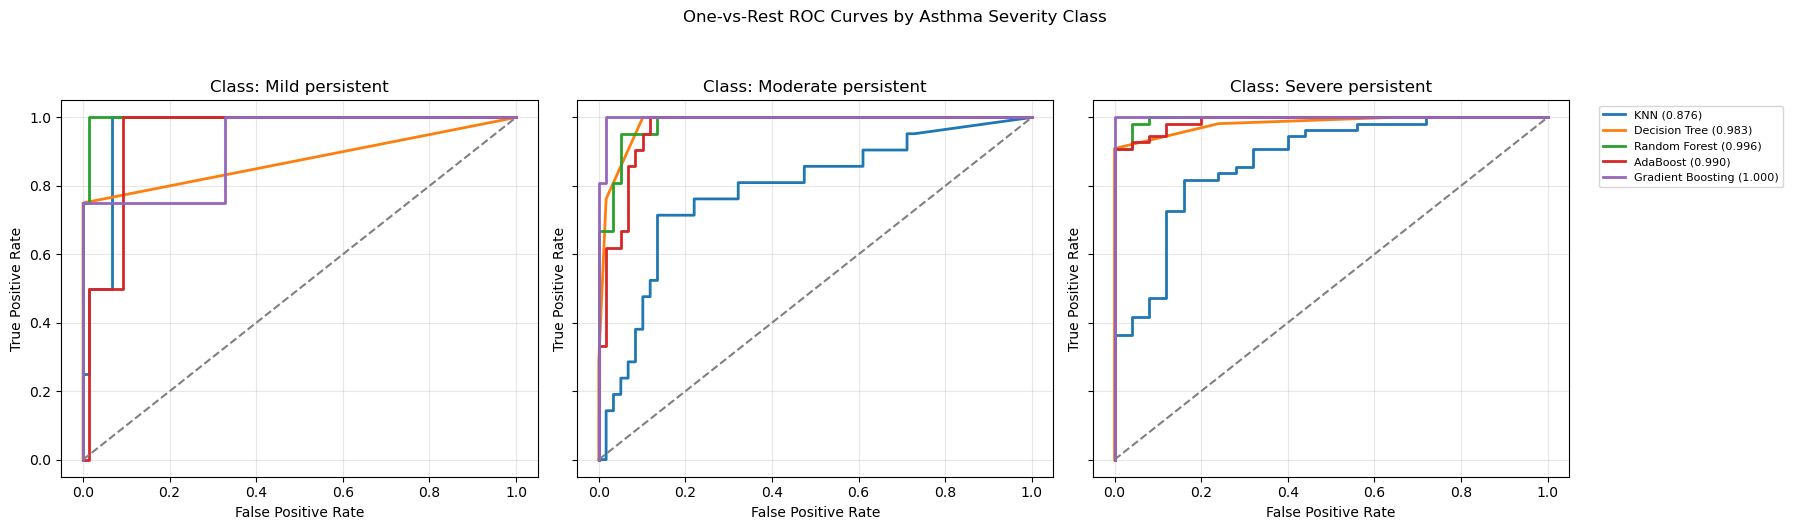

In [51]:
fig, axes = plt.subplots(
    1,
    len(classes),
    figsize=(18, 5),
    sharex=True,
    sharey=True
)

for class_index, class_name in enumerate(classes):

    ax = axes[class_index]

    for model_name, output in prediction_outputs.items():

        y_proba = output["y_proba"]

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, class_index],
            y_proba[:, class_index]
        )

        class_auc = auc(fpr, tpr)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{model_name} ({class_auc:.3f})"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray"
    )

    ax.set_title(f"Class: {class_name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.grid(alpha=0.3)

axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.suptitle(
    "One-vs-Rest ROC Curves by Asthma Severity Class",
    y=1.05
)

plt.tight_layout()
plt.show()

In [52]:
plt.figure(figsize=(10, 8))

# کد رسم ROC کلی را دوباره اجرا کنید و سپس:
plt.savefig(
    "asthma_severity_roc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x800 with 0 Axes>

In [53]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

label_encoder = LabelEncoder()

# براساس کل برچسب‌ها encoder را تنظیم می‌کنیم
label_encoder.fit(y)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

encoded_classes = np.arange(
    len(label_encoder.classes_)
)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(encoded_classes)

print("\nMapping:")
for number, label in enumerate(
    label_encoder.classes_
):
    print(number, "=", label)

Original classes:
['Mild persistent' 'Moderate persistent' 'Severe persistent']

Encoded classes:
[0 1 2]

Mapping:
0 = Mild persistent
1 = Moderate persistent
2 = Severe persistent


In [54]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

n_classes = len(label_encoder.classes_)

models = {
    "KNN": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        objective="multiclass",
        num_class=n_classes,
        verbosity=-1,
        random_state=42,
        n_jobs=-1
    )
}

In [55]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

results = []
trained_models = {}
prediction_outputs = {}

for model_name, model in models.items():

    print(f"Training: {model_name}")

    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(
        X_train,
        y_train_encoded
    )

    y_pred_encoded = pipeline.predict(X_test)

    y_proba = pipeline.predict_proba(X_test)

    # اطمینان از integer بودن خروجی مدل
    y_pred_encoded = y_pred_encoded.astype(int)

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test_encoded,
            y_pred_encoded
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_test_encoded,
            y_pred_encoded
        ),
        "Precision Macro": precision_score(
            y_test_encoded,
            y_pred_encoded,
            average="macro",
            zero_division=0
        ),
        "Recall Macro": recall_score(
            y_test_encoded,
            y_pred_encoded,
            average="macro",
            zero_division=0
        ),
        "F1 Macro": f1_score(
            y_test_encoded,
            y_pred_encoded,
            average="macro",
            zero_division=0
        ),
        "F1 Weighted": f1_score(
            y_test_encoded,
            y_pred_encoded,
            average="weighted",
            zero_division=0
        ),
        "MCC": matthews_corrcoef(
            y_test_encoded,
            y_pred_encoded
        ),
        "ROC-AUC Macro": roc_auc_score(
            y_test_encoded,
            y_proba,
            multi_class="ovr",
            average="macro",
            labels=encoded_classes
        )
    }

    results.append(result)

    trained_models[model_name] = pipeline

    prediction_outputs[model_name] = {
        "y_pred_encoded": y_pred_encoded,
        "y_proba": y_proba
    }

    print(
        classification_report(
            y_test_encoded,
            y_pred_encoded,
            labels=encoded_classes,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Macro",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        column: "{:.4f}"
        for column in results_df.columns
        if column != "Model"
    })
)

Training: KNN
                     precision    recall  f1-score   support

    Mild persistent       0.50      0.25      0.33         4
Moderate persistent       0.62      0.48      0.54        21
  Severe persistent       0.82      0.93      0.87        55

           accuracy                           0.78        80
          macro avg       0.65      0.55      0.58        80
       weighted avg       0.75      0.78      0.76        80

Training: Decision Tree
                     precision    recall  f1-score   support

    Mild persistent       1.00      0.75      0.86         4
Moderate persistent       0.78      1.00      0.88        21
  Severe persistent       1.00      0.91      0.95        55

           accuracy                           0.93        80
          macro avg       0.93      0.89      0.89        80
       weighted avg       0.94      0.93      0.93        80

Training: Random Forest
                     precision    recall  f1-score   support

    Mild persist

,Model,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,MCC,ROC-AUC Macro
0,Gradient Boosting,0.9750,0.9106,0.9710,0.9106,0.9342,0.9746,0.9465,0.9715
1,LightGBM,0.9750,0.9106,0.9710,0.9106,0.9342,0.9746,0.9465,0.9970
2,Decision Tree,0.9250,0.8864,0.9259,0.8864,0.8948,0.9273,0.8530,0.9467
3,XGBoost,0.9625,0.8947,0.8864,0.8947,0.8904,0.9629,0.9191,0.9965
4,Random Forest,0.9125,0.7540,0.9352,0.7540,0.8146,0.9063,0.8020,0.9913
5,AdaBoost,0.9000,0.6228,0.5745,0.6228,0.5966,0.8793,0.7802,0.9675
6,KNN,0.7750,0.5512,0.6492,0.5512,0.5819,0.7579,0.4659,0.8760


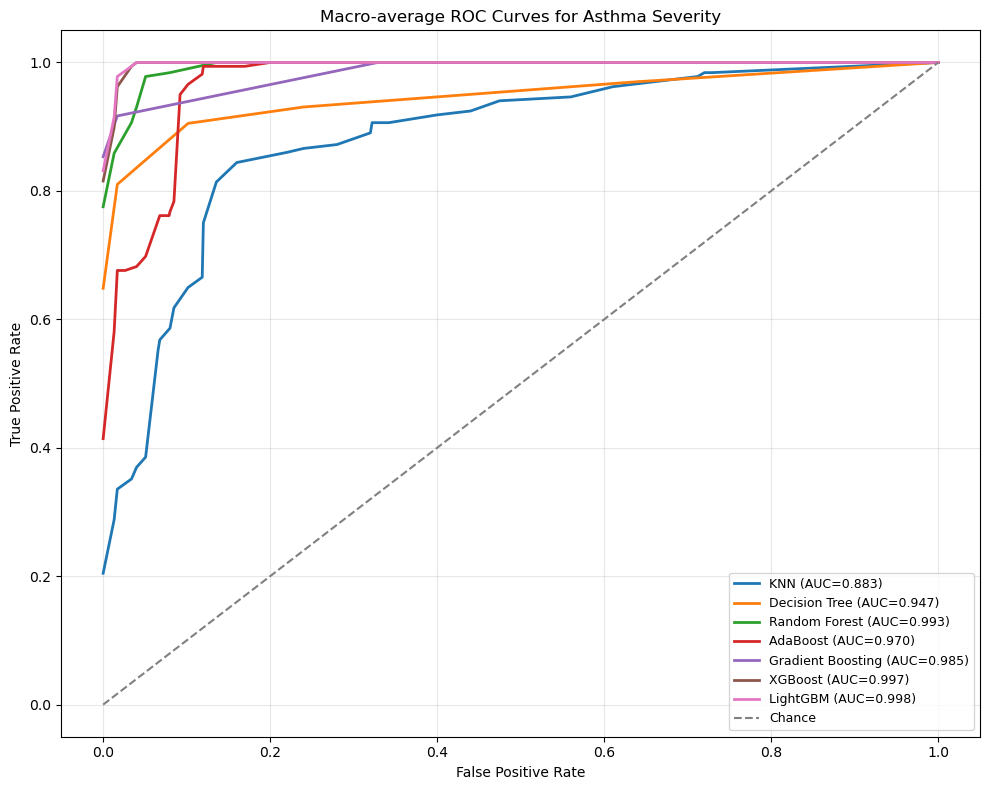

In [56]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_test_binary = label_binarize(
    y_test_encoded,
    classes=encoded_classes
)

plt.figure(figsize=(10, 8))

for model_name, output in prediction_outputs.items():

    y_proba = output["y_proba"]

    fpr_all = []
    tpr_all = []

    for class_index in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, class_index],
            y_proba[:, class_index]
        )

        fpr_all.append(fpr)
        tpr_all.append(tpr)

    all_fpr = np.unique(
        np.concatenate(fpr_all)
    )

    mean_tpr = np.zeros_like(all_fpr)

    for fpr, tpr in zip(
        fpr_all,
        tpr_all
    ):
        mean_tpr += np.interp(
            all_fpr,
            fpr,
            tpr
        )

    mean_tpr /= n_classes

    macro_auc = auc(
        all_fpr,
        mean_tpr
    )

    plt.plot(
        all_fpr,
        mean_tpr,
        linewidth=2,
        label=f"{model_name} (AUC={macro_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Chance"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "Macro-average ROC Curves for Asthma Severity"
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()